In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('marketing_campaign.xlsx', engine='openpyxl')
print(df.head(100))
df.shape
df.describe()

       ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0    5524        1957  Graduation         Single  58138.0        0         0   
1    2174        1954  Graduation         Single  46344.0        1         1   
2    4141        1965  Graduation       Together  71613.0        0         0   
3    6182        1984  Graduation       Together  26646.0        1         0   
4    5324        1981         PhD        Married  58293.0        1         0   
..    ...         ...         ...            ...      ...      ...       ...   
95   7516        1983  Graduation        Married  30096.0        1         0   
96   7247        1960  Graduation          Widow  47916.0        0         1   
97  11100        1972  Graduation       Divorced  51813.0        1         1   
98   4646        1951    2n Cycle        Married  78497.0        0         0   
99   3037        1983         PhD        Married  50150.0        0         0   

   Dt_Customer  Recency  MntWines  ... 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_excel('marketing_campaign.xlsx')

# Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)

# Independent variables
X = df.drop('Response', axis=1)

# Dependent variable
y = df['Response']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.8638392857142857
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       379
           1       0.68      0.22      0.33        69

    accuracy                           0.86       448
   macro avg       0.78      0.60      0.63       448
weighted avg       0.84      0.86      0.83       448



In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [12]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [5]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_excel('marketing_campaign.xlsx')

# Fill missing values
df = df.fillna(0)

# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Features and Target
X = df.drop('Response', axis=1)
y = df['Response']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM Model
svm_model = SVC(kernel='rbf', random_state=42)

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.859375

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       379
           1       0.65      0.19      0.29        69

    accuracy                           0.86       448
   macro avg       0.76      0.58      0.61       448
weighted avg       0.84      0.86      0.82       448



C:\Users\WIN 11\AppData\Local\Temp\ipykernel_21928\455397089.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [6]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_excel('marketing_campaign.xlsx')

# Fill missing values
df = df.fillna(0)

# Convert categorical columns to numeric
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Independent variables
X = df.drop('Response', axis=1)

# Dependent variable
y = df['Response']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Decision Tree Model
dt_model = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy'
    random_state=42,
    max_depth=5
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.859375

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       379
           1       0.62      0.23      0.34        69

    accuracy                           0.86       448
   macro avg       0.74      0.60      0.63       448
weighted avg       0.83      0.86      0.83       448



C:\Users\WIN 11\AppData\Local\Temp\ipykernel_21928\3581021967.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [7]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# Load dataset
df = pd.read_excel('marketing_campaign.xlsx')

# Fill missing values
df = df.fillna(0)

# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Independent variables
X = df.drop('Response', axis=1)

# Dependent variable
y = df['Response']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Train Model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

C:\Users\WIN 11\AppData\Local\Temp\ipykernel_21928\4028932342.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Accuracy: 0.8727678571428571

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       379
           1       0.68      0.33      0.45        69

    accuracy                           0.87       448
   macro avg       0.78      0.65      0.69       448
weighted avg       0.86      0.87      0.85       448


Confusion Matrix:
[[368  11]
 [ 46  23]]


In [13]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [11]:
import pandas as pd 
from  sklearn.preprocessing import LabelEncoder
df = pd.read_excel('marketing_campaign.xlsx', engine='openpyxl')

ae = LabelEncoder ()
df['Marital_Status'] = ae.fit_transform(df['Marital_Status'])
print(df['Marital_Status'])

0       4
1       4
2       5
3       5
4       3
       ..
2235    3
2236    5
2237    2
2238    5
2239    3
Name: Marital_Status, Length: 2240, dtype: int64


In [13]:
df.tail(80)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2160,5667,1964,PhD,3,60896.0,0,1,2012-10-11,90,1013,...,6,0,0,0,0,0,0,3,11,1
2161,902,1980,Graduation,5,62994.0,1,0,2014-03-04,74,224,...,6,0,0,0,0,0,0,3,11,0
2162,977,1957,Graduation,5,47320.0,0,1,2013-08-01,10,200,...,6,0,0,0,0,0,0,3,11,0
2163,7313,1949,2n Cycle,6,74859.0,0,0,2013-06-03,63,570,...,3,0,0,0,1,0,0,3,11,0
2164,7600,1992,Basic,4,15253.0,1,0,2013-10-28,13,1,...,7,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,3,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,5,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,2,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,5,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


In [16]:
print(f"Number of Dupicate rows:{df.duplicated().sum()}")

Number of Dupicate rows:0


In [12]:
df['Education'].unique()

<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

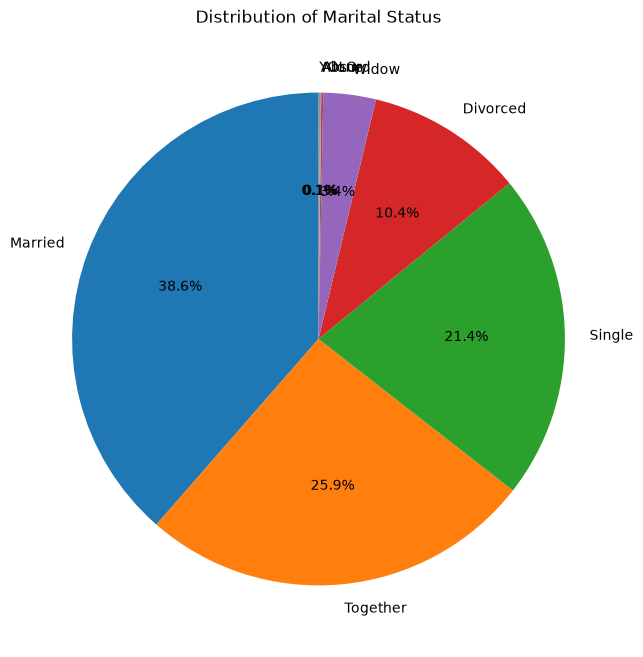

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('marketing_campaign.xlsx', engine='openpyxl')

# Count values in Marital_Status column
marital_counts = df['Marital_Status'].value_counts()

# Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    marital_counts,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Marital Status')
plt.show()